In [2]:
# learned that problem is coming from converting to datetime
# and importing monthly average

In [3]:
import os
import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm_notebook
from itertools import product

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from typing import Union

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# use daily averages
# fix structure mix match
# update so seasonal component is used


In [4]:
# Define SARIMA model
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [5]:
# Forecasting 
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    
    if method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df_train[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [6]:
# read in the merged station datasets
dfs = {}
for index in range(0, 6) :
  df = pd.read_csv('merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df


In [7]:
#drop these two features because they mess up station 4. Temporary solution
for key in dfs.keys():
  dfs[key].drop(['SWC_50'], axis = 1, inplace = True)
  dfs[key].drop(['T_50'], axis = 1, inplace = True)


In [8]:
#drop flag feature and null values

for station, df in dfs.items() :
  # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
  df = df.drop('Flag', axis = 1)
  # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
  df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
  df_new.dropna(inplace=True)
  dfs[station] = df_new

In [9]:
#Vectorize wind
for station, df in dfs.items() :
  # convert wind velocity and wind direction to a wind vector
  wv = df.pop('Windspeed')

  # Convert to radians.
  wd_rad = df.pop('Winddirection')*np.pi / 180

  # Calculate the wind x and y components.
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

In [10]:
# # Remove periodicity in time data (remove daily and yearly periodicity)
# day = 24*60*60
# year = (365.2425)*day

# for station, df in dfs.items() :
#   timestamp_s = (df.index).map(pd.Timestamp.timestamp)

#   df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
#   df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
#   df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
#   df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

#   dfs[station] = df

In [11]:
# create one standard metric for PPT
for key in dfs.keys():
  dfs[key]['PPT'] = (dfs[key].pop('Ppt_soil') + dfs[key].pop('Ppt_met'))/2

In [12]:
#Normalize all the data
for key in dfs.keys():
  dfs[key] = (dfs[key] - dfs[key].min())/(dfs[key].max()-dfs[key].min())

In [13]:
#only use data shared all together: indexes that are none null for each station

index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)

index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)


print(len(index_int))


45185


# Create Multi-Index DF for all Station Data

In [14]:
feats = dfs['Station1'].columns.tolist()

stations = list(dfs.keys())

In [15]:
index = index_int

cols = pd.MultiIndex.from_product([stations,feats], names = ['Station', 'Feature'])

In [16]:
for station, df in dfs.items():
  cols_new = []
  for col in df.columns.tolist():
    cols_new.append(f"{station} {col}")
  df.columns = cols_new

In [17]:
lis = [dfs[key].loc[index] for key in dfs.keys()]

data = pd.concat(lis, axis = 1)

data.head()

,Station1 SWC_5,Station1 SWC_10,Station1 SWC_20,Station1 T_5,Station1 T_10,Station1 T_20,Station1 Tair,Station1 RH,Station1 Srad,Station1 Wx,...,Station6 SWC_20,Station6 T_5,Station6 T_10,Station6 T_20,Station6 Tair,Station6 RH,Station6 Srad,Station6 Wx,Station6 Wy,Station6 PPT
2016-02-20 13:00:00,0.139623,0.219626,0.208054,0.409553,0.414440,0.417014,0.912188,0.870606,0.350557,0.318500,...,0.254545,0.414988,0.415822,0.409511,0.646701,0.719745,0.326054,0.327554,0.519249,0.0
2016-02-20 15:00:00,0.143396,0.224299,0.208054,0.451220,0.447961,0.434964,0.917929,0.812634,0.367328,0.353486,...,0.254545,0.443966,0.443078,0.425892,0.670312,0.622687,0.380189,0.385141,0.561426,0.0
2016-02-20 16:00:00,0.147170,0.228972,0.214765,0.463618,0.462260,0.445890,0.924424,0.799389,0.392486,0.368937,...,0.254545,0.455739,0.457308,0.435931,0.694965,0.600243,0.443144,0.382056,0.563651,0.0
2016-02-20 17:00:00,0.143396,0.228972,0.208054,0.468089,0.472808,0.456296,0.927341,0.797453,0.213525,0.369872,...,0.254545,0.458682,0.463821,0.445178,0.695660,0.602265,0.196865,0.413326,0.599024,0.0
2016-02-20 18:00:00,0.143396,0.228972,0.214765,0.457317,0.476090,0.465140,0.924894,0.823484,0.078887,0.390298,...,0.254545,0.454381,0.462615,0.450991,0.686806,0.640077,0.076036,0.429337,0.603361,0.0


In [18]:
df = pd.DataFrame(data = data.values, index = index, columns = cols)

In [19]:
df.index = pd.to_datetime(df.index)
df = df.resample('M').mean()

In [36]:
df

Station     Station1                                                     
Feature        SWC_5    SWC_10    SWC_20       T_5      T_10      T_20   
2016-02-29  0.344101  0.393645  0.319612  0.305793  0.333057  0.347403  \
2016-03-31  0.339618  0.397858  0.426373  0.381489  0.415576  0.432795   
2016-04-30  0.469436  0.425537  0.360598  0.439707  0.482103  0.505385   
2016-05-31  0.413648  0.436646  0.430876  0.503294  0.555005  0.585371   
2016-06-30  0.311664  0.355782  0.369011  0.617949  0.682594  0.720157   
...              ...       ...       ...       ...       ...       ...   
2021-02-28  0.589847  0.418815  0.551784  0.194412  0.204867  0.206798   
2021-03-31  0.418117  0.289764  0.402405  0.354948  0.383763  0.396471   
2021-04-30  0.299581  0.153706  0.192813  0.438263  0.478288  0.499892   
2021-05-31  0.581076  0.420536  0.553962  0.479286  0.525053  0.550767   
2021-06-30  0.766601  0.569570  0.741060  0.471478  0.520189  0.551878   

Station                                             ...  Station6             
Feature         Tair        RH      Srad        Wx  ...    SWC_20       T_5   
2016-02-29  0.878242  0.832927  0.166975  0.480922  ...  0.397522  0.308249  \
2016-03-31  0.893441  0.816180  0.196539  0.432232  ...  0.382472  0.390749   
2016-04-30  0.903310  0.836580  0.178998  0.425891  ...  0.364422  0.467282   
2016-05-31  0.915006  0.880230  0.179941  0.410645  ...  0.358050  0.545491   
2016-06-30  0.934664  0.848015  0.248402  0.414970  ...  0.279909  0.682673   
...              ...       ...       ...       ...  ...       ...       ...   
2021-02-28  0.847301  0.884910  0.124146  0.456434  ...  0.502246  0.194381   
2021-03-31  0.887730  0.811014  0.198553  0.425645  ...  0.426393  0.364575   
2021-04-30  0.898679  0.836309  0.187786  0.432830  ...  0.285985  0.458065   
2021-05-31  0.913820  0.904315  0.199544  0.407136  ...  0.499576  0.517466   
2021-06-30  0.910289  0.944980  0.170835  0.472658  ...  0.642153  0.501764   

Station                                                                  
Feature         T_10      T_20      Tair        RH      Srad        Wx   
2016-02-29  0.319151  0.329593  0.503639  0.702588  0.166049  0.569293  \
2016-03-31  0.404731  0.420548  0.559374  0.665975  0.191416  0.539631   
2016-04-30  0.484608  0.508740  0.598071  0.705064  0.199027  0.539285   
2016-05-31  0.567114  0.598965  0.646114  0.771554  0.180316  0.522156   
2016-06-30  0.710387  0.749018  0.722077  0.699340  0.244657  0.516050   
...              ...       ...       ...       ...       ...       ...   
2021-02-28  0.196106  0.197160  0.411654  0.318578  0.130221  0.544681   
2021-03-31  0.375523  0.387819  0.556151  0.621588  0.193726  0.529725   
2021-04-30  0.475106  0.497375  0.598734  0.674042  0.185829  0.538798   
2021-05-31  0.536993  0.562545  0.669304  0.804825  0.199464  0.528931   
2021-06-30  0.523364  0.553729  0.657540  0.892861  0.162056  0.574094   

Station                         
Feature           Wy       PPT  
2016-02-29  0.571570  0.002467  
2016-03-31  0.610031  0.003235  
2016-04-30  0.639965  0.003071  
2016-05-31  0.667813  0.002799  
2016-06-30  0.645205  0.000722  
...              ...       ...  
2021-02-28  0.601788  0.000882  
2021-03-31  0.619839  0.001108  
2021-04-30  0.643048  0.001731  
2021-05-31  0.657135  0.002613  
2021-06-30  0.629669  0.011234  

[65 rows x 72 columns]

# Data Split

In [20]:
# #create Df of our target Values

# target_station = 'Station6'

# target_names = ['SWC_5']

# target_df = df[target_station][target_names]

# target_df.shape

In [21]:
test_len = 10
total_len = len(df.Station1.SWC_5)
train_len = total_len - test_len

In [22]:
df_train = df.Station1.SWC_5[:train_len]
df_test = df.Station1.SWC_5[train_len:]
df_total = df.Station1.SWC_5

In [23]:
# #Create DF of all our data not the target
# non_targets = list(dfs.keys())

# non_targets.remove('Station6')

# train_df = df[non_targets]

# train_df.shape

In [24]:
# train=[]
# test=[]

# exog = []


# for station, feature in df:
#     if feature == "SWC_5" and station != 'Station6':
#         train.extend(df[station].SWC_5)
#     elif feature == "SWC_5":
#         test.extend(df[station].SWC_5)

In [25]:
# # define exog (not used right now)
# df_exog = []
# for i in exog:
#     df_exog.extend(pd.DataFrame(i[::24*30]))


In [26]:
# df_train = pd.DataFrame(train[::24*30])
# df_test = pd.DataFrame(test[::24*30])
# df_total = pd.concat([df_train, df_test], ignore_index=True)

# train_len = len(df_train)
# test_len = len(df_test)

# total_len = train_len + test_len

In [27]:
# Define range of parameter's to check
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12


In [28]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(df_train, None, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

[(0, 0, 0, 0), 58.91812616616237]
[(0, 0, 0, 1), 21.289169830535297]
[(0, 0, 1, 0), -34.43830709964714]
[(0, 0, 1, 1), -40.26577507467853]
[(0, 1, 0, 0), 12.034647632189607]
[(0, 1, 0, 1), -9.077903033225015]
[(0, 1, 1, 0), -39.107605195587105]
[(0, 1, 1, 1), -45.27308019077346]
[(1, 0, 0, 0), -67.08011586931934]
[(1, 0, 0, 1), -65.58387430029026]
[(1, 0, 1, 0), -65.54827286380232]
[(1, 0, 1, 1), -63.54129699513297]
[(1, 1, 0, 0), -67.96728638165585]
[(1, 1, 0, 1), -67.25482523270281]
[(1, 1, 1, 0), -67.3993918677665]
[(1, 1, 1, 1), -66.04286309110857]


,"(p,q,P,Q)",AIC
0,"(1, 1, 0, 0)",-67.967286
1,"(1, 1, 1, 0)",-67.399392
2,"(1, 1, 0, 1)",-67.254825
3,"(1, 0, 0, 0)",-67.080116
4,"(1, 1, 1, 1)",-66.042863
5,"(1, 0, 0, 1)",-65.583874
6,"(1, 0, 1, 0)",-65.548273
7,"(1, 0, 1, 1)",-63.541297
8,"(0, 1, 1, 1)",-45.273080
9,"(0, 0, 1, 1)",-40.265775


In [29]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(df_train, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  SWC_5   No. Observations:                   55
Model:               SARIMAX(1, 0, 1)   Log Likelihood                  36.230
Date:                Mon, 04 Sep 2023   AIC                            -66.460
Time:                        12:19:46   BIC                            -60.550
Sample:                    02-29-2016   HQIC                           -64.187
                         - 08-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9696      0.038     25.743      0.000       0.896       1.043
ma.L1         -0.2780      0.157     -1.772      0.076      -0.586       0.030
sigma2         0.0149      0.003      4.840      0.0

In [30]:
pred_df = df_test.copy()

In [31]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len/3)

In [32]:
pred_df['SARIMA'] = rolling_forecast(df_total, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df.SARIMA

[0.16633476629029584,
 0.16130167477032772,
 0.15642087859313938,
 0.15168776948341128,
 0.14709787860673545,
 0.14264687235029985,
 0.13833054823124433,
 0.1341448309288247,
 0.13008576843663894,
 0.12614952833128232,
 0.12233239415390862,
 0.11863076190128101]

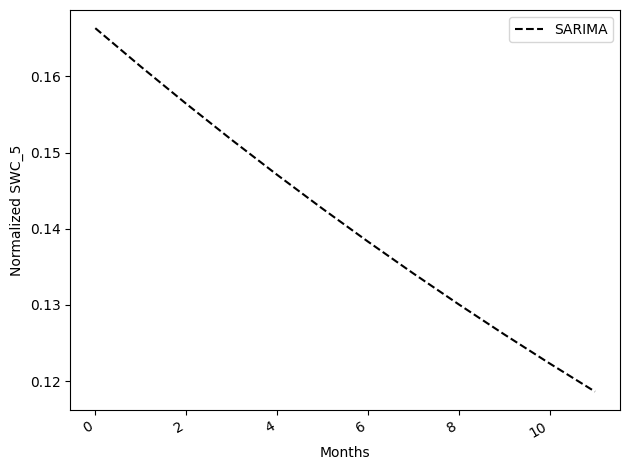

In [33]:
# visualize predictions
fig, ax = plt.subplots()

# ax.plot(df_total)
# ax.plot(df_test[:10], 'b-', label='actual')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Months')
ax.set_ylabel('Normalized SWC_5')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

In [34]:
# Evaluate 
mse=np.mean((df_test-pred_df.SARIMA[:10])**2)
mse

0.1336213408903356

In [35]:
# Calculate MAE
mae = mean_absolute_error(df_test, pred_df.SARIMA)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(df_test, pred_df.SARIMA))

# Calculate MAPE
mape = np.mean(np.abs((df_test - pred_df.SARIMA) / df_test)) * 100

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

ValueError: Found input variables with inconsistent numbers of samples: [10, 12]